In [5]:
import random  # import python's built-in library for random numbers

# Step 1: Parameters
POP_SIZE = 6       # population size
GENES = 5          # number of bits (to represent 0–31, we need 5 bits)
GENERATIONS = 10   # how many iterations
MUTATION_RATE = 0.1  # probability of mutation

# Fitness function: f(x) = x^2
def fitness(x):
    return x ** 2

# Generate random chromosome (5-bit binary string)
def random_chromosome():
    return ''.join(random.choice('01') for _ in range(GENES))

# Decode binary string to integer
def decode(chromosome):
    return int(chromosome, 2)

# Selection: pick two best parents
def selection(population):
    population = sorted(population, key=lambda c: fitness(decode(c)), reverse=True)
    return population[:2]

# Crossover: single point
def crossover(parent1, parent2):
    point = random.randint(1, GENES - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

# Mutation: flip a bit with some probability
def mutate(chromosome):
    chromosome = list(chromosome)
    for i in range(GENES):
        if random.random() < MUTATION_RATE:
            chromosome[i] = '1' if chromosome[i] == '0' else '0'
    return ''.join(chromosome)

# Main GA loop
population = [random_chromosome() for _ in range(POP_SIZE)]

for gen in range(GENERATIONS):
    print(f"\nGeneration {gen+1}:")
    for chrom in population:
        print(f"Chromosome: {chrom}, x={decode(chrom)}, Fitness={fitness(decode(chrom))}")

    # Selection
    parents = selection(population)

    # Crossover + Mutation
    next_population = []
    while len(next_population) < POP_SIZE:
        child1, child2 = crossover(parents[0], parents[1])
        next_population.append(mutate(child1))
        if len(next_population) < POP_SIZE:
            next_population.append(mutate(child2))

    population = next_population

# Final Result
best = max(population, key=lambda c: fitness(decode(c)))
print("\nBest Solution Found:")
print(f"Chromosome: {best}, x={decode(best)}, Fitness={fitness(decode(best))}")


Generation 1:
Chromosome: 00010, x=2, Fitness=4
Chromosome: 01010, x=10, Fitness=100
Chromosome: 11001, x=25, Fitness=625
Chromosome: 11111, x=31, Fitness=961
Chromosome: 00011, x=3, Fitness=9
Chromosome: 00001, x=1, Fitness=1

Generation 2:
Chromosome: 11001, x=25, Fitness=625
Chromosome: 11001, x=25, Fitness=625
Chromosome: 11001, x=25, Fitness=625
Chromosome: 11111, x=31, Fitness=961
Chromosome: 10101, x=21, Fitness=441
Chromosome: 01011, x=11, Fitness=121

Generation 3:
Chromosome: 11000, x=24, Fitness=576
Chromosome: 11110, x=30, Fitness=900
Chromosome: 10101, x=21, Fitness=441
Chromosome: 11001, x=25, Fitness=625
Chromosome: 11101, x=29, Fitness=841
Chromosome: 11001, x=25, Fitness=625

Generation 4:
Chromosome: 11101, x=29, Fitness=841
Chromosome: 11110, x=30, Fitness=900
Chromosome: 11101, x=29, Fitness=841
Chromosome: 11100, x=28, Fitness=784
Chromosome: 10111, x=23, Fitness=529
Chromosome: 11110, x=30, Fitness=900

Generation 5:
Chromosome: 01110, x=14, Fitness=196
Chromosom

In [6]:
# Returns the maximum value that
# can be put in a knapsack of capacity W
def knapsackRec(W, val, wt, n):

    # Base Case
    if n == 0 or W == 0:
        return 0

    pick = 0

    # Pick nth item if it does not exceed the capacity of knapsack
    if wt[n - 1] <= W:
        pick = val[n - 1] + knapsackRec(W - wt[n - 1], val, wt, n - 1)
    
    # Don't pick the nth item
    notPick = knapsackRec(W, val, wt, n - 1)
     
    return max(pick, notPick)

def knapsack(W, val, wt):
    n = len(val)
    return knapsackRec(W, val, wt, n)

if __name__ == "__main__":
    val = [1, 2, 3]
    wt = [4, 5, 1]
    W = 4

    print(knapsack(W, val, wt))

3


Initial best distance: 393.34503065398195
Final best distance: 283.47309575899504


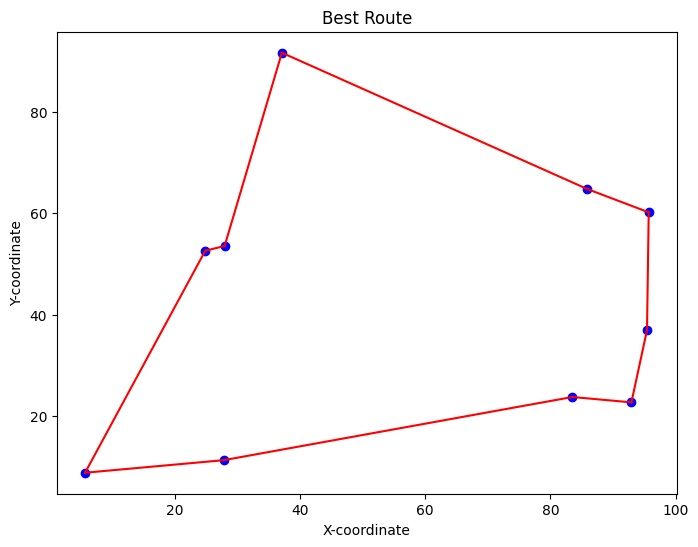

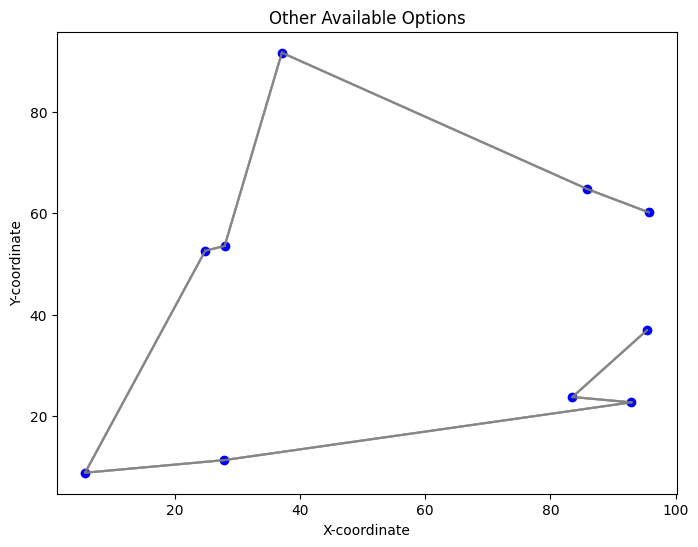

In [1]:
#skill - travelling salesman problem with genetic algorithm

import numpy as np
import random
import matplotlib.pyplot as plt

num_cities = 10
city_coordinates = np.random.rand(num_cities, 2) * 100

def distance(city1, city2):
    return np.linalg.norm(city1 - city2)

def total_distance(route):
    total = 0
    for i in range(len(route) - 1):
        total += distance(city_coordinates[route[i]], city_coordinates[route[i + 1]])
    total += distance(city_coordinates[route[-1]], city_coordinates[route[0]])
    return total

def initial_population(pop_size, num_cities):
    population = []
    for _ in range(pop_size):
        route = list(range(num_cities))
        random.shuffle(route)
        population.append(route)
    return population

def selection(population, num_parents):
    selected_parents = []
    for _ in range(num_parents):
        tournament = random.sample(population, 5)
        selected_parents.append(min(tournament, key=total_distance))
    return selected_parents

def crossover(parent1, parent2):
    start = random.randint(0, len(parent1) - 1)
    end = random.randint(start, len(parent1))
    child = [None] * len(parent1)
    for i in range(start, end):
        child[i] = parent1[i]
    remaining_cities = [city for city in parent2 if city not in child]
    idx = 0
    for i in range(len(parent1)):
        if child[i] is None:
            child[i] = remaining_cities[idx]
            idx += 1
    return child

def mutation(route):
    idx1, idx2 = random.sample(range(len(route)), 2)
    route[idx1], route[idx2] = route[idx2], route[idx1]
    return route

def genetic_algorithm(population, pop_size, num_generations):
    for _ in range(num_generations):
        parents = selection(population, 2)
        offspring = crossover(parents[0], parents[1])
        if random.random() < 0.2:
            offspring = mutation(offspring)
        population.append(offspring)
        population = sorted(population, key=total_distance)[:pop_size]
    return population

def main():
    pop_size = 100
    num_generations = 500
    population = initial_population(pop_size, num_cities)
    best_route = min(population, key=total_distance)
    best_distance = total_distance(best_route)
    print("Initial best distance:", best_distance)
    population = genetic_algorithm(population, pop_size, num_generations)
    best_route = min(population, key=total_distance)
    best_distance = total_distance(best_route)
    print("Final best distance:", best_distance)
    plt.figure(figsize=(8, 6))
    plt.scatter(city_coordinates[:, 0], city_coordinates[:, 1], c='blue')
    for i in range(len(best_route) - 1):
        plt.plot([city_coordinates[best_route[i], 0], city_coordinates[best_route[i + 1], 0]],
                 [city_coordinates[best_route[i], 1], city_coordinates[best_route[i + 1], 1]], c='red')
    plt.plot([city_coordinates[best_route[-1], 0], city_coordinates[best_route[0], 0]],
             [city_coordinates[best_route[-1], 1], city_coordinates[best_route[0], 1]], c='red')
    plt.title('Best Route')
    plt.xlabel('X-coordinate')
    plt.ylabel('Y-coordinate')
    plt.show()
    plt.figure(figsize=(8, 6))
    plt.scatter(city_coordinates[:, 0], city_coordinates[:, 1], c='blue')
    for route in population:
        if route != best_route:
            for i in range(len(route) - 1):
                plt.plot([city_coordinates[route[i], 0], city_coordinates[route[i + 1], 0]],
                         [city_coordinates[route[i], 1], city_coordinates[route[i + 1], 1]], c='gray', alpha=0.1)
            plt.plot([city_coordinates[route[-1], 0], city_coordinates[route[0], 0]],
                     [city_coordinates[route[-1], 1], city_coordinates[route[0], 1]], c='none', alpha=0.1)
    plt.title('Other Available Options')
    plt.xlabel('X-coordinate')
    plt.ylabel('Y-coordinate')
    plt.show()

if __name__ == "__main__":
    main()


In [2]:
import random  # import python's built-in library for random numbers

# Step 1: Parameters
POP_SIZE = 6       # population size
GENES = 5          # number of bits (to represent 0–31, we need 5 bits)
GENERATIONS = 10   # how many iterations
MUTATION_RATE = 0.1  # probability of mutation

# Fitness function: f(x) = x^2
def fitness(x):
    return x ** 2

# Generate random chromosome (5-bit binary string)
def random_chromosome():
    return ''.join(random.choice('01') for _ in range(GENES))

# Decode binary string to integer
def decode(chromosome):
    return int(chromosome, 2)

# Selection: pick two best parents
def selection(population):
    population = sorted(population, key=lambda c: fitness(decode(c)), reverse=True)
    return population[:2]

# Crossover: single point
def crossover(parent1, parent2):
    point = random.randint(1, GENES - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

# Mutation: flip a bit with some probability
def mutate(chromosome):
    chromosome = list(chromosome)
    for i in range(GENES):
        if random.random() < MUTATION_RATE:
            chromosome[i] = '1' if chromosome[i] == '0' else '0'
    return ''.join(chromosome)

# Main GA loop
population = [random_chromosome() for _ in range(POP_SIZE)]

for gen in range(GENERATIONS):
    print(f"\nGeneration {gen+1}:")
    for chrom in population:
        print(f"Chromosome: {chrom}, x={decode(chrom)}, Fitness={fitness(decode(chrom))}")

    # Selection
    parents = selection(population)

    # Crossover + Mutation
    next_population = []
    while len(next_population) < POP_SIZE:
        child1, child2 = crossover(parents[0], parents[1])
        next_population.append(mutate(child1))
        if len(next_population) < POP_SIZE:
            next_population.append(mutate(child2))

    population = next_population

# Final Result
best = max(population, key=lambda c: fitness(decode(c)))
print("\nBest Solution Found:")
print(f"Chromosome: {best}, x={decode(best)}, Fitness={fitness(decode(best))}")



Generation 1:
Chromosome: 11101, x=29, Fitness=841
Chromosome: 01111, x=15, Fitness=225
Chromosome: 10101, x=21, Fitness=441
Chromosome: 01111, x=15, Fitness=225
Chromosome: 10001, x=17, Fitness=289
Chromosome: 11100, x=28, Fitness=784

Generation 2:
Chromosome: 10110, x=22, Fitness=484
Chromosome: 11001, x=25, Fitness=625
Chromosome: 01100, x=12, Fitness=144
Chromosome: 11101, x=29, Fitness=841
Chromosome: 11100, x=28, Fitness=784
Chromosome: 11001, x=25, Fitness=625

Generation 3:
Chromosome: 10100, x=20, Fitness=400
Chromosome: 01100, x=12, Fitness=144
Chromosome: 11100, x=28, Fitness=784
Chromosome: 11101, x=29, Fitness=841
Chromosome: 11101, x=29, Fitness=841
Chromosome: 11101, x=29, Fitness=841

Generation 4:
Chromosome: 11101, x=29, Fitness=841
Chromosome: 11101, x=29, Fitness=841
Chromosome: 11101, x=29, Fitness=841
Chromosome: 11101, x=29, Fitness=841
Chromosome: 11101, x=29, Fitness=841
Chromosome: 11101, x=29, Fitness=841

Generation 5:
Chromosome: 11101, x=29, Fitness=841
